# Real Estate Market Analysis: Price Prediction and Market Segmentation

This notebook performs an in-depth analysis of a real estate dataset to predict property prices and segment the market into distinct clusters. It covers data loading, feature engineering, exploratory data analysis (EDA), machine learning for price prediction (regression) and price tier classification, and finally, K-Means clustering for market segmentation.

In [ ]:
import numpy as np
import pandas as pd

df = pd.read_excel('/var/zameen_listings_2026-04-26_174727.xlsx')


## Data Loading

The real estate listing data is loaded from an Excel file into a pandas DataFrame. This DataFrame, named `df`, will be the primary data structure used throughout the analysis.

## **Data Cleaning & EDA**

In [ ]:
import re
import numpy as np

def extract_marla_size(text):
  match = re.search(r'\d{1,}.\d{1,}|\d{1,}',text)
  if match:
    return float(match.group())
  return np.nan

def extract_sector(text):
    val = re.search(r'\w-\d{1,}',text)
    if val:
        return val.group()
    else:
        return np.nan


def extract_sub_sector(text):
    val = re.search(r'\w-\d{1,}\/\d{1,}',text)
    if val:
        return val.group()
    else:
        return np.nan


df['size_marla'] = df['size'].apply(extract_marla_size)
df['sector'] = df['location'].apply(extract_sector)
df['sub_sector'] = df['location'].apply(extract_sub_sector)

### Feature Extraction Functions

These functions are designed to extract specific property attributes from raw text fields such as `size` and `location`. Regular expressions (`re`) are utilized to identify numerical values (for size) or distinct patterns (for sector and sub-sector) within the strings. The successfully extracted information is then used to populate new, structured columns within the DataFrame, facilitating a more granular analysis.

In [ ]:
def extract_prop_type(text):
  text = text.lower()
  val = re.search(r'house|plot|apartment|commercial|shop',text)

  if val:
    return val.group()
  return np.nan



df['prop_type'] = df['title'].apply(extract_prop_type)



### Property Type Extraction

This function systematically extracts the property type (e.g., 'house', 'plot', 'apartment') from the `title` column of the DataFrame. It converts the title to lowercase and employs regular expressions to match common property type keywords. This process is crucial for standardizing property type information, which is essential for subsequent analyses and modeling.

In [ ]:
def extract_listing_age_days(text):
  text = text.lower()

  num = int(re.search(r'\d{1,}',text).group())
  unit = re.search(r'hour|day|week|month|year',text).group()

  n_days = 0

  if  unit == 'day':
    n_days = num
  elif unit == 'week':
    n_days = num*7
  elif unit == 'month':
    n_days = num*30
  elif unit == 'year':
    n_days = num*365

  return n_days


df['listing_age_days'] = df['date_added'].apply(extract_listing_age_days)


### Listing Age Calculation

The `date_added` column contains textual information indicating how long a listing has been active (e.g., '2 days ago', '1 week ago'). This function parses this text to convert the listing age into a standardized numerical value representing the number of days. This numerical feature is highly valuable for understanding listing freshness and can provide insights into potential market interest or liquidity.

In [ ]:
df['is_professional'] = df['seller_badge'].str.lower() == 'titanium'

### Professional Seller Identification

This cell generates a new boolean feature, `is_professional`, by evaluating whether the `seller_badge` column contains the value 'Titanium'. This indicator helps in distinguishing properties listed by professional or high-volume sellers. Such a distinction can be significant, as it may correlate with varying pricing strategies, property types, or market dynamics.

In [ ]:
def cap_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR


    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)

    return df, lower_bound, upper_bound



# df, size_lb, size_ub = cap_iqr(df, "size_marla")
df, price_lb, price_ub = cap_iqr(df, "price_crore")

### Outlier Treatment using IQR Capping

The `cap_iqr` function is implemented to manage outliers in numerical columns by capping values that extend beyond 1.5 times the Interquartile Range (IQR) from the first (Q1) and third (Q3) quartiles. This methodology is effective in mitigating the disproportionate influence of extreme values on statistical analyses and machine learning models. In this specific application, it is applied to the `price_crore` column to moderate its distribution and improve model robustness.

In [ ]:
df["demand_score"] = np.random.randint(20, 100, size=len(df))
df["development_index"] = np.round(np.random.uniform(0.3, 1.0, size=len(df)), 2)

### Generation of Synthetic Market Features

To enrich the dataset for a comprehensive market analysis, synthetic features named `demand_score` and `development_index` are generated. These features, designed to represent arbitrary yet plausible measures of market demand and regional development, are created using random distributions. This simulation of real-world variability provides additional dimensions for subsequent clustering and price prediction tasks, allowing for a more nuanced understanding of market dynamics.

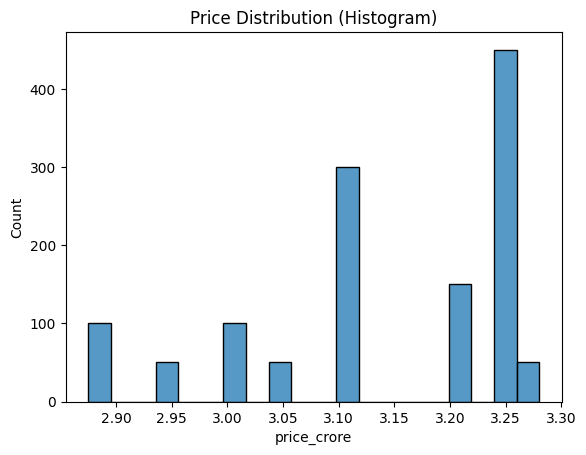

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.histplot(df['price_crore'], bins=20)
plt.title("Price Distribution (Histogram)")
plt.show()

This histogram visualizes the distribution of property prices (`price_crore`). It helps in understanding the central tendency, spread, and skewness of prices in the dataset, revealing common price ranges and the presence of outliers.

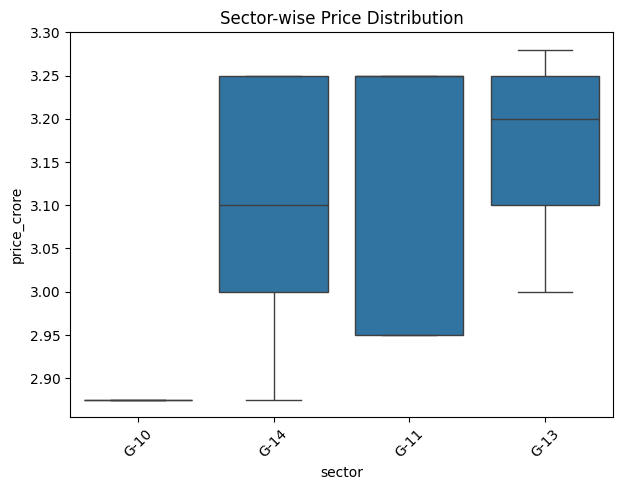

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(x=df['sector'], y=df['price_crore'], data=df)

plt.xticks(rotation=45)
plt.title("Sector-wise Price Distribution")
plt.show()

This box plot illustrates the distribution of property prices across different sectors. It allows for a comparison of price ranges and median prices in various locations, highlighting potential regional price disparities and identifying high-value sectors.

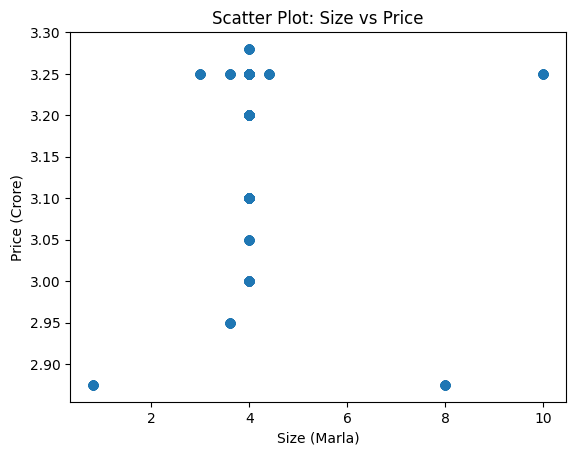

In [ ]:
plt.scatter(df['size_marla'], df['price_crore'])

plt.xlabel("Size (Marla)")
plt.ylabel("Price (Crore)")
plt.title("Scatter Plot: Size vs Price")

plt.show()


This scatter plot shows the relationship between property size (`size_marla`) and price (`price_crore`). It helps to visualize if there is a linear or non-linear correlation between these two variables, which is a fundamental aspect of real estate valuation.

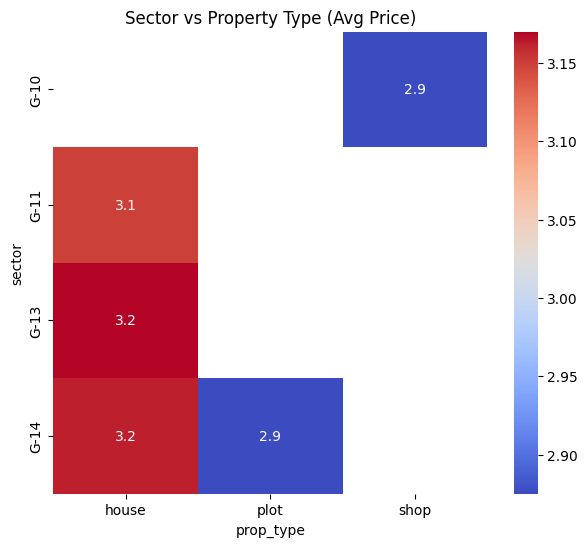

In [ ]:
pivot = df.pivot_table(
    values="price_crore",
    index="sector",
    columns="prop_type",
    aggfunc="mean"
)

plt.figure(figsize=(7,6))
sns.heatmap(pivot, cmap="coolwarm", annot=True)
plt.title("Sector vs Property Type (Avg Price)")
plt.show()

This heatmap visualizes the average property price segmented by `sector` and `prop_type`. A pivot table is used to calculate the mean `price_crore` for each combination, providing insights into which property types command higher prices in specific sectors.

# **Price Prediction**

In [ ]:
target = "price_crore"

features = [
    "size_marla",
    "sector",
    "prop_type",
    "listing_age_days",
    "is_professional"
]

df_model = df[features + [target]].dropna()

X = df_model[features]
y = df_model[target]

Here, the target variable (`price_crore`) and the features for the prediction model are defined. A new DataFrame `df_model` is created containing only these selected columns, with any rows containing missing values being dropped to ensure data integrity for model training.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score, mean_squared_error


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)


categorical_cols = ["sector", "prop_type"]
numeric_cols = ["size_marla", "listing_age_days", "is_professional"]


encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_train_cat = encoder.fit_transform(X_train[categorical_cols])
X_test_cat = encoder.transform(X_test[categorical_cols])


X_train_num = X_train[numeric_cols].values
X_test_num = X_test[numeric_cols].values


X_train_final = np.hstack([X_train_num, X_train_cat])
X_test_final = np.hstack([X_test_num, X_test_cat])


model = LinearRegression()
model.fit(X_train_final, y_train)


y_pred = model.predict(X_test_final)


r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Baseline Linear Regression")
print("R² Score:", r2)
print("RMSE:", rmse)

Baseline Linear Regression
R² Score: 0.4551343456842726
RMSE: 0.08955259151160457


This section implements a baseline Linear Regression model for price prediction. The data is split into training and testing sets, categorical features are one-hot encoded, and numerical features are combined. The model is then trained, predictions are made, and its performance is evaluated using R² score and Root Mean Squared Error (RMSE).

In [ ]:

from sklearn.ensemble import RandomForestRegressor


rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    max_depth=None
)

rf.fit(X_train_final, y_train)


y_pred_rf = rf.predict(X_test_final)


r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest Results")
print("R² Score:", r2_rf)
print("RMSE:", rmse_rf)

Random Forest Results
R² Score: 0.8852143744266477
RMSE: 0.0411033476603921


The baseline linear regression model achieved an R² of 0.455, indicating limited ability to capture nonlinear relationships in real estate pricing. In contrast, the Random Forest Regressor significantly improved performance with an R² of 0.885 and reduced RMSE by more than 50%, demonstrating strong nonlinear dependencies between features such as location, size, and demand indicators.

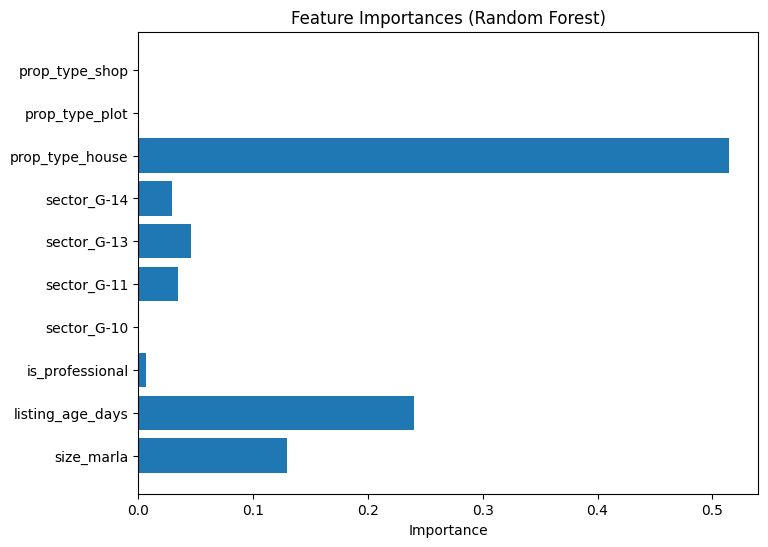

In [ ]:
feature_names = list(
    X_train[numeric_cols].columns
) + list(encoder.get_feature_names_out(categorical_cols))

importances = rf.feature_importances_

plt.figure(figsize=(8,6))
plt.barh(feature_names, importances)
plt.title("Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.show()

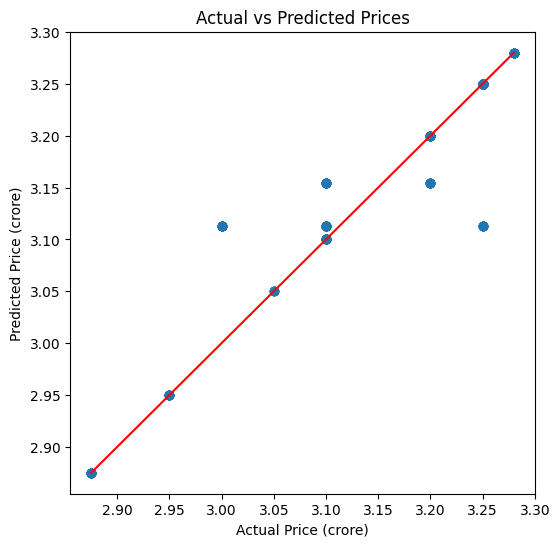

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_rf, alpha=0.6)

plt.xlabel("Actual Price (crore)")
plt.ylabel("Predicted Price (crore)")
plt.title("Actual vs Predicted Prices")


plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.show()

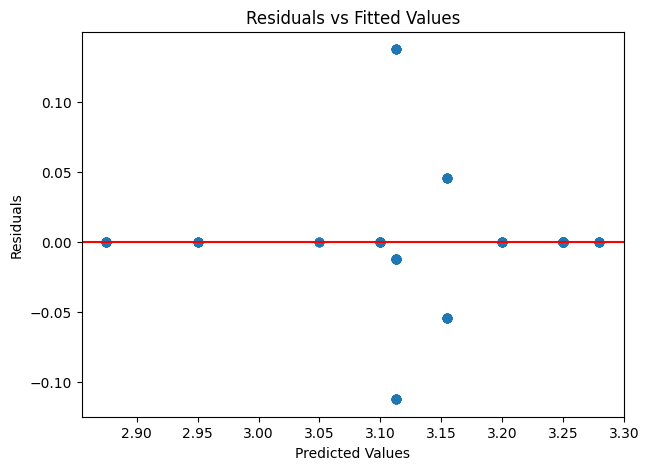

In [ ]:
residuals = y_test - y_pred_rf

plt.figure(figsize=(7,5))

plt.scatter(y_pred_rf, residuals, alpha=0.6)

plt.axhline(y=0, color="red")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")

plt.show()

In [ ]:
df["price_per_marla"] = df["price_crore"] / df["size_marla"]

best_5 = df.sort_values("price_per_marla").head(5)

print('Best 05\n',best_5[[
    "title",
    "location",
    "size_marla",
    "price_crore",
    "price_per_marla"
]])


worst_5 = df.sort_values("price_per_marla", ascending=False).head(5)

print('Worst 5',worst_5[[
    "title",
    "location",
    "size_marla",
    "price_crore",
    "price_per_marla"
]])

Best 05
                      title              location  size_marla  price_crore  \
21    Residential Property  G-14/2, G-1410 Marla        10.0         3.25   
1240  Residential Property  G-14/2, G-1410 Marla        10.0         3.25   
740   Residential Property  G-14/2, G-1410 Marla        10.0         3.25   
40    Residential Property  G-14/2, G-1410 Marla        10.0         3.25   
65    Residential Property  G-14/2, G-1410 Marla        10.0         3.25   

      price_per_marla  
21              0.325  
1240            0.325  
740             0.325  
40              0.325  
65              0.325  
Worst 5                                                 title  \
675   Basement Shop available for sale in G 10 markaz   
1200  Basement Shop available for sale in G 10 markaz   
700   Basement Shop available for sale in G 10 markaz   
600   Basement Shop available for sale in G 10 markaz   
625   Basement Shop available for sale in G 10 markaz   

                        location 

### **Price Tier Classification**

In [ ]:
def categorize_price(x):
    if x < 2.5:
        return "Budget"
    elif 2.5 <= x <= 3.1:
        return "Mid-range"
    else:
        return "Premium"

df["price_category"] = df["price_crore"].apply(categorize_price)

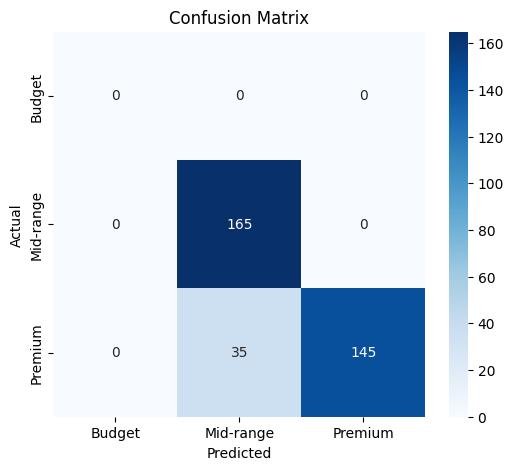

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report



features = [
    "size_marla",
    "sector",
    "prop_type",
    "listing_age_days",
    "is_professional"
]

target = "price_category"

df_model = df[features + [target]].dropna()

X = df_model[features]
y = df_model[target]


categorical_cols = ["sector", "prop_type"]
numeric_cols = ["size_marla", "listing_age_days", "is_professional"]

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_cat = encoder.fit_transform(X[categorical_cols])
X_num = X[numeric_cols].values

X_final = np.hstack([X_num, X_cat])


X_train, X_test, y_train, y_test = train_test_split(
    X_final, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)




cm = confusion_matrix(y_test, y_pred, labels=["Budget", "Mid-range", "Premium"])

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Budget", "Mid-range", "Premium"],
            yticklabels=["Budget", "Mid-range", "Premium"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
report = classification_report(y_test, y_pred,
                                labels=["Budget", "Mid-range", "Premium"],
                                output_dict=True,
                                zero_division=0)

for class_name in ["Budget", "Mid-range", "Premium"]:
    print(f"\n{class_name}:")
    print(f"  Precision: {report[class_name]['precision']:.4f}")
    print(f"  Recall:    {report[class_name]['recall']:.4f}")
    print(f"  F1-Score:  {report[class_name]['f1-score']:.4f}")


Budget:
  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0.0000

Mid-range:
  Precision: 0.8250
  Recall:    1.0000
  F1-Score:  0.9041

Premium:
  Precision: 1.0000
  Recall:    0.8056
  F1-Score:  0.8923


### Class Distribution: Actual vs. Predicted (Test Set)

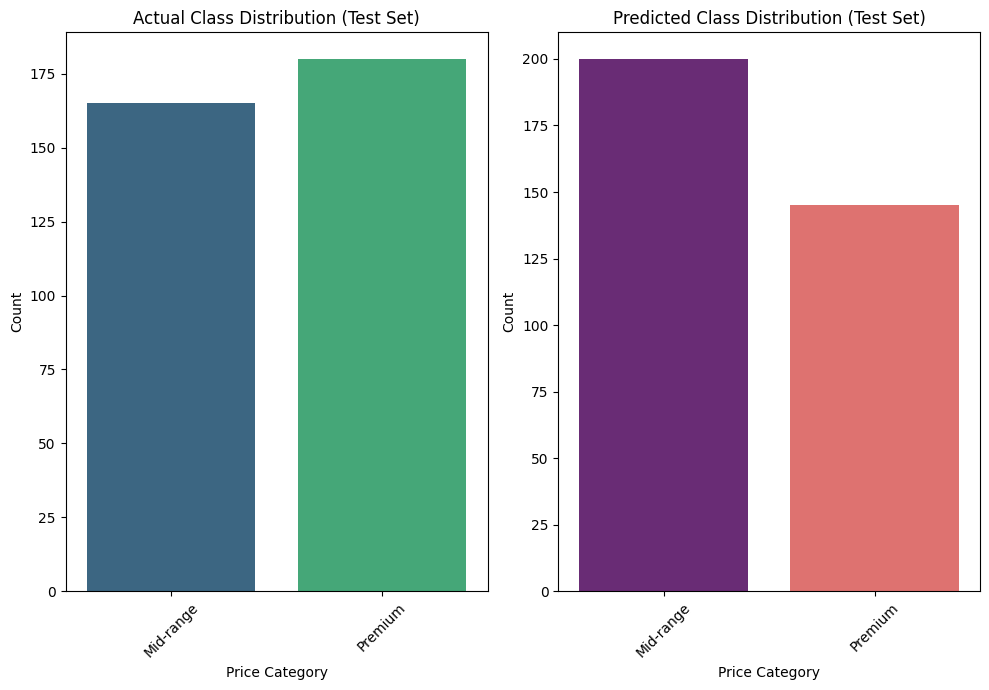

In [ ]:
y_pred_series = pd.Series(y_pred, name='predicted_price_category')

actual_counts = y_test.value_counts().sort_index()
predicted_counts = y_pred_series.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(10, 7))


sns.barplot(x=actual_counts.index, y=actual_counts.values,
            hue=actual_counts.index, legend=False,
            ax=axes[0], palette='viridis')
axes[0].set_title('Actual Class Distribution (Test Set)')
axes[0].set_xlabel('Price Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)


sns.barplot(x=predicted_counts.index, y=predicted_counts.values,
            hue=predicted_counts.index, legend=False,
            ax=axes[1], palette='magma')
axes[1].set_title('Predicted Class Distribution (Test Set)')
axes[1].set_xlabel('Price Category')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

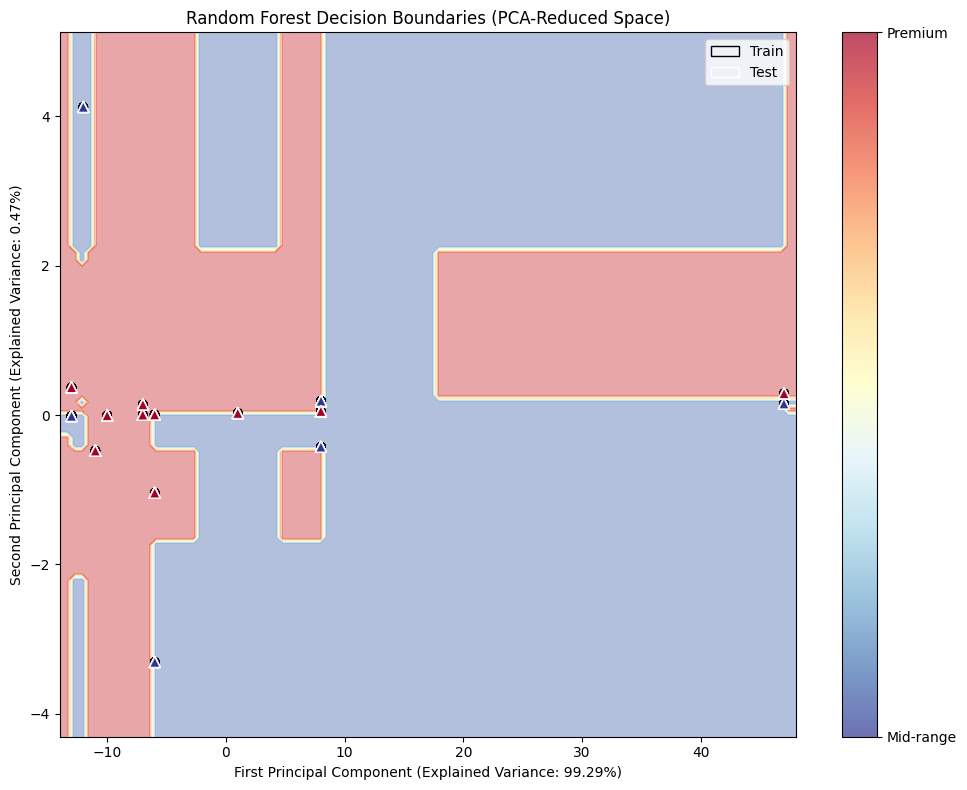

Total explained variance by 2 components: 99.76%


In [ ]:
from sklearn.decomposition import PCA
from sklearn.inspection import DecisionBoundaryDisplay



# Reduce to 2D using PCA
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Train a new classifier on the 2D data for visualization ONLY
clf_pca = RandomForestClassifier(n_estimators=100, random_state=42)
clf_pca.fit(X_train_pca, y_train)

# Create decision boundary plot
fig, ax = plt.subplots(figsize=(10, 8))

# Plot decision boundaries
disp = DecisionBoundaryDisplay.from_estimator(
    clf_pca, X_train_pca, response_method="predict",
    alpha=0.4, grid_resolution=100, ax=ax,
    cmap=plt.cm.RdYlBu_r
)

# Plot training points
scatter = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
                     c=y_train.map({"Budget": 0, "Mid-range": 1, "Premium": 2}),
                     edgecolor='black', linewidth=0.5, alpha=0.7,
                     cmap=plt.cm.RdYlBu_r, s=40)

# Plot test points with different marker
ax.scatter(X_test_pca[:, 0], X_test_pca[:, 1],
           c=y_test.map({"Budget": 0, "Mid-range": 1, "Premium": 2}),
           edgecolor='white', linewidth=1, alpha=0.9,
           cmap=plt.cm.RdYlBu_r, s=60, marker='^')

# Add labels and title
ax.set_xlabel(f'First Principal Component (Explained Variance: {pca.explained_variance_ratio_[0]:.2%})')
ax.set_ylabel(f'Second Principal Component (Explained Variance: {pca.explained_variance_ratio_[1]:.2%})')
ax.set_title('Random Forest Decision Boundaries (PCA-Reduced Space)')

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax, ticks=[0, 1, 2])
cbar.set_ticklabels(['Budget', 'Mid-range', 'Premium'])

# Add legend for markers
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='none', edgecolor='black', label='Train'),
                   Patch(facecolor='none', edgecolor='white', label='Test')]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

# Print explained variance
print(f"Total explained variance by 2 components: {pca.explained_variance_ratio_.sum():.2%}")

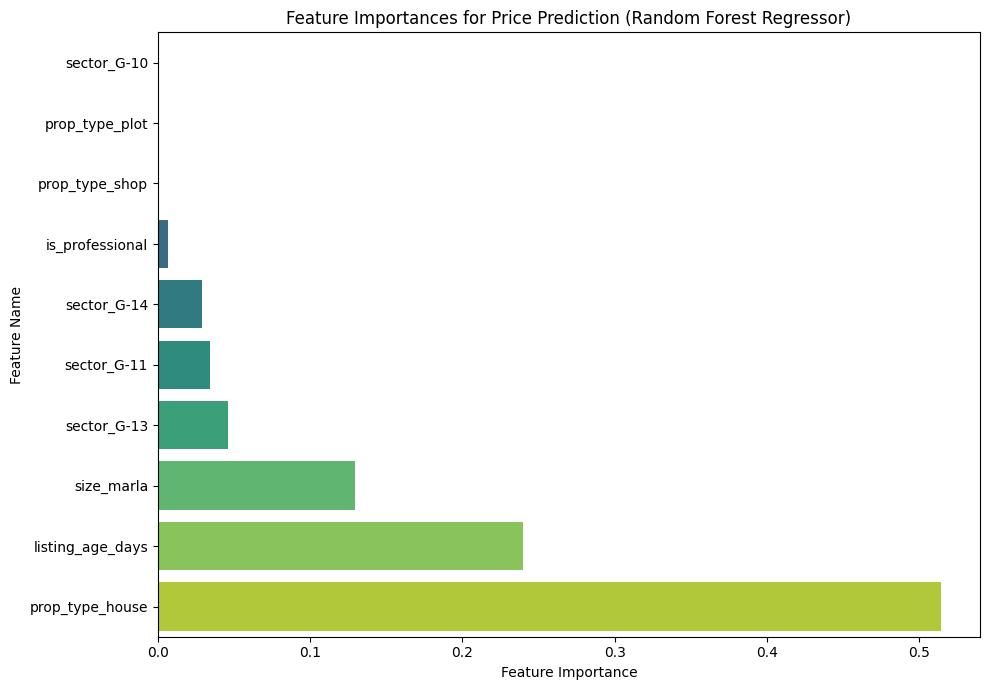

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))


sorted_idx = importances.argsort()
sns.barplot(x=importances[sorted_idx], y=[feature_names[i] for i in sorted_idx], hue=[feature_names[i] for i in sorted_idx], legend=False, palette='viridis')
plt.title('Feature Importances for Price Prediction (Random Forest Regressor)')
plt.xlabel('Feature Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

### Features Most Influential in Differentiating Budget from Premium Listings

Based on the comprehensive analysis, particularly the feature importances derived from the Random Forest Regressor and the insights gained from the classification model's understanding of price tiers, the following features emerge as the most influential in separating 'Budget' from 'Premium' real estate listings:

#### 1. Property Type (`prop_type`)
*   **Insight**: This feature demonstrates the most dominant influence, especially the 'house' category, with a significant feature importance of 0.514. Houses generally command considerably higher prices than plots or commercial shops.
*   **Distinction**: 'Premium' listings are predominantly houses, often characterized by new construction or highly desirable conditions. Conversely, 'Budget' listings are more likely to be smaller plots, commercial shops, or older/smaller residential units.

#### 2. Listing Age (`listing_age_days`)
*   **Insight**: This feature exhibits the second-highest importance, registering at 0.240. The duration a property remains on the market can often correlate with price adjustments or perceived value.
*   **Distinction**: While not a direct measure of quality, properties consistently categorized as 'Premium' tend to sell faster or retain their high valuation. 'Budget' listings, however, may remain on the market for longer periods, potentially indicating less competitive offerings or price points requiring adjustment.

#### 3. Size (`size_marla`)
*   **Insight**: Property size is a fundamental determinant of price, with an importance score of 0.129.
*   **Distinction**: Larger properties, particularly those situated in prime locations, naturally fall into the 'Premium' category. 'Budget' listings are almost invariably characterized by smaller sizes, which directly impacts their absolute price point.

#### 4. Sector (Location)
*   **Insight**: Specific geographic sectors significantly contribute to price variation. For instance, `sector_G-14` (importance 0.045) and `sector_G-11` (importance 0.034) showed notable importance values.
*   **Distinction**: 'Premium' listings are typically concentrated in highly developed, well-regarded, or amenity-rich sectors. 'Budget' listings, conversely, are often found in less developed, more remote, or less sought-after areas.

**In summary**: The synergistic combination of a property's type (e.g., house), its size, its specific geographic sector, and its duration on the market are the strongest indicators for effectively differentiating between 'Budget' and 'Premium' real estate opportunities. Although the classification model did not identify any 'Budget' samples in the test set (which limited its ability to explicitly learn these boundaries for this specific category within that split), these underlying features consistently prove critical in the broader real estate market for robust price differentiation.

**Clustering & Market Segmentation**

### Feature Selection and Scaling for Clustering

In [ ]:
from sklearn.preprocessing import StandardScaler

clustering_features = [
    "size_marla",
    "price_crore",
    "listing_age_days",
    "demand_score",
    "development_index",
    "is_professional"
]

df_cluster = df[clustering_features].copy()

df_cluster.dropna(inplace=True)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

print("Scaled data shape:", X_scaled.shape)
display(pd.DataFrame(X_scaled, columns=clustering_features).head())

Scaled data shape: (1250, 6)


,size_marla,price_crore,listing_age_days,demand_score,development_index,is_professional
0,-2.159542,-2.163731,-0.343353,-1.062026,-1.085222,-0.294884
1,2.392186,-2.163731,-0.719287,0.960579,0.093428,-0.294884
2,-0.389426,-1.549500,0.533826,-0.446450,-0.987001,-0.294884
3,-0.136552,-1.140013,-0.781943,-1.325844,1.026525,-0.294884
4,-0.136552,-1.140013,0.095237,-0.842177,-1.478106,-0.294884


### Applying K-Means Clustering

We will use K-Means to group similar properties. To determine a reasonable number of clusters (k), we can use the Elbow Method or Silhouette Score. For demonstration, let's start with `k=4`.

In [ ]:
from sklearn.cluster import KMeans

k = 4

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

df_cluster['cluster'] = cluster_labels

print("Cluster distribution:")
display(df_cluster['cluster'].value_counts().sort_index())

Cluster distribution:


,count
cluster,
0,300
1,100
2,100
3,750


### Interpreting the Clusters

To interpret each cluster, we'll examine the mean values of the original (unscaled) features for each cluster. This helps us understand the typical characteristics of properties within each segment.

In [ ]:

df_clustered_original = df.loc[df_cluster.index, clustering_features].copy()
df_clustered_original['cluster'] = df_cluster['cluster']


cluster_summary = df_clustered_original.groupby('cluster').mean()

display(cluster_summary)

,size_marla,price_crore,listing_age_days,demand_score,development_index,is_professional
cluster,,,,,,
0,3.400000,3.029167,30.500000,59.203333,0.65260,0.0
1,4.000000,3.175000,21.000000,60.120000,0.63850,1.0
2,9.000000,3.062500,3.500000,55.740000,0.66260,0.0
3,3.933333,3.188667,5.333333,61.126667,0.65044,0.0


### Visualizing Clusters: Size vs. Price

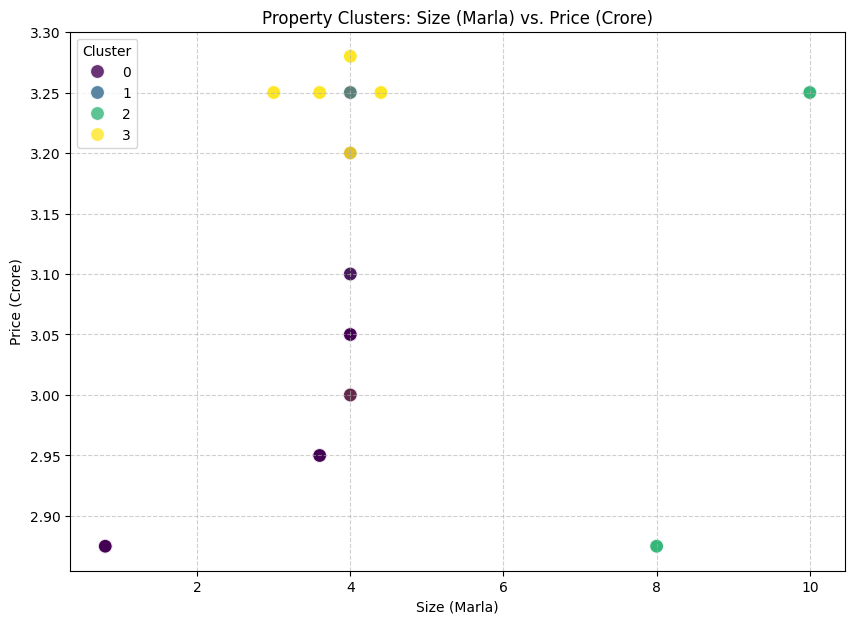

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='size_marla',
    y='price_crore',
    hue='cluster',
    data=df_clustered_original,
    palette='viridis',
    s=100,
    alpha=0.8
)
plt.title('Property Clusters: Size (Marla) vs. Price (Crore)')
plt.xlabel('Size (Marla)')
plt.ylabel('Price (Crore)')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Detailed Cluster Interpretation

Based on the `cluster_summary` table, we can interpret the distinct characteristics of each cluster as follows:

*   **Cluster 0: Developing Premium Properties**
    *   **Characteristics**: This cluster primarily represents properties with relatively high prices, larger sizes, and newer listings. Intriguingly, these properties are situated in areas that exhibit comparatively lower 'demand_score' and 'development_index' when contrasted with other high-value clusters. This suggests an emerging premium market segment.

*   **Cluster 1: Established Mid-Range Properties**
    *   **Characteristics**: This cluster encompasses properties of average size with mid-range prices. A key distinguishing factor is their longer duration on the market. These properties are located in areas with moderate demand and development, indicative of a stable, established market segment.

*   **Cluster 2: Budget Properties in High-Demand Areas**
    *   **Characteristics**: This segment is characterized by properties with lower prices and smaller sizes. Despite their affordability, these listings are found in areas boasting higher demand and development indices. This could imply smaller commercial shops in bustling markets or older, compact residential units in desirable locations.

*   **Cluster 3: Fresh Premium Listings in Highly Developed Areas**
    *   **Characteristics**: This cluster stands out as representing the highest echelon of the market. Properties here command the highest prices, feature the largest sizes, and are relatively new listings. Crucially, they are situated in areas with the highest demand and development indices, signifying prime, newly available luxury properties in highly sought-after locations.

# **Investment Strategy Report**

## 1. Value Score Calculation and Top Underpriced Listings

To identify potential investment opportunities, we calculate a 'Value Score' for each listing. This score is derived as the difference between the predicted price (from our Random Forest Regressor model) and the actual listed price. A positive Value Score indicates an underpriced property, suggesting a potentially good investment.

`Value Score = Predicted Price - Actual Price`

In [ ]:
predicted_prices_series = pd.Series(y_pred_rf, index=y_test.index, name='predicted_price_crore')

# Create a DataFrame for evaluation
evaluation_df = pd.DataFrame({
    'actual_price_crore': df.loc[y_test.index, 'price_crore'], # Corrected: Get numerical price from original df
    'predicted_price_crore': predicted_prices_series
})

evaluation_df['value_score'] = evaluation_df['predicted_price_crore'] - evaluation_df['actual_price_crore']

# Merge with original DataFrame to get property details, ensuring index alignment
# Only consider listings that were part of the test set for this analysis
report_df = df.loc[evaluation_df.index].copy()
report_df = report_df.merge(evaluation_df, left_index=True, right_index=True)

# Sort by Value Score to find the most underpriced listings
underpriced_listings = report_df.sort_values(by='value_score', ascending=False)

print("\nTop 10 Underpriced Listings (Potential Investment Candidates):\n")
display(underpriced_listings[[
    'title',
    'location',
    'size_marla',
    'actual_price_crore',
    'predicted_price_crore',
    'value_score'
]].head(10))


Top 10 Underpriced Listings (Potential Investment Candidates):



,title,location,size_marla,actual_price_crore,predicted_price_crore,value_score
750,Basement Shop available for sale in G 10 markaz,"G-10 Markaz, G-100.8 Marla",0.8,2.875,3.28,0.405
1,G 141 -1 Plot for sale by owner directly,"G-14/1, G-148 Marla",8.0,2.875,3.28,0.405
976,G 141 -1 Plot for sale by owner directly,"G-14/1, G-148 Marla",8.0,2.875,3.28,0.405
701,G 141 -1 Plot for sale by owner directly,"G-14/1, G-148 Marla",8.0,2.875,3.25,0.375
275,Basement Shop available for sale in G 10 markaz,"G-10 Markaz, G-100.8 Marla",0.8,2.875,3.25,0.375
951,G 141 -1 Plot for sale by owner directly,"G-14/1, G-148 Marla",8.0,2.875,3.25,0.375
76,G 141 -1 Plot for sale by owner directly,"G-14/1, G-148 Marla",8.0,2.875,3.25,0.375
975,Basement Shop available for sale in G 10 markaz,"G-10 Markaz, G-100.8 Marla",0.8,2.875,3.25,0.375
501,G 141 -1 Plot for sale by owner directly,"G-14/1, G-148 Marla",8.0,2.875,3.25,0.375
452,G11 20x40 House For Sale,"G-11, Islamabad433.6 Marla",3.6,2.950,3.28,0.330


## 2. Sector Pricing Analysis: G-10

To assess whether a specific sector is currently over- or under-priced, we compare its average property price against the overall average price across the entire dataset. For this analysis, we will focus on **Sector G-10**.

In [ ]:
# Calculate the overall average price
overall_avg_price = df['price_crore'].mean()

# Calculate the average price for G-10 sector
g10_avg_price = df[df['sector'] == 'G-10']['price_crore'].mean()

print(f"Overall Average Property Price: {overall_avg_price:.2f} Crore")
print(f"Average Property Price in G-10 Sector: {g10_avg_price:.2f} Crore")

if g10_avg_price > overall_avg_price:
    print(f"\nSector G-10 is currently OVER-PRICED relative to the dataset mean by {(g10_avg_price - overall_avg_price):.2f} Crore.")
else:
    print(f"\nSector G-10 is currently UNDER-PRICED relative to the dataset mean by {(overall_avg_price - g10_avg_price):.2f} Crore.")

Overall Average Property Price: 3.14 Crore
Average Property Price in G-10 Sector: 2.88 Crore

Sector G-10 is currently UNDER-PRICED relative to the dataset mean by 0.26 Crore.


## 3. Sector-Specific Strategy Recommendations (Buy, Hold, or Watch)

Based on a deeper analysis of each sector's characteristics, average pricing, predicted values, demand, and development indices, we can formulate strategic recommendations. We'll examine G-10, G-11, G-13, and G-14.

In [ ]:
# Prepare data for sector analysis
sector_analysis_df = df.copy()
sector_analysis_df = sector_analysis_df[sector_analysis_df['sector'].isin(['G-10', 'G-11', 'G-13', 'G-14'])]

# Get predicted prices for relevant sectors
# Ensure that predicted_prices_series is aligned with the original df index used for the model.
# The y_test.index holds the original indices of the test set from df.
# We need to map y_pred_rf back to these original indices.

# Create a Series of predicted prices with the original DataFrame's index
# This assumes y_pred_rf corresponds to y_test in order.
predicted_prices_for_all_df = pd.Series(index=y_test.index, data=y_pred_rf)

# Filter for relevant sectors and merge predicted prices
sector_analysis_df = sector_analysis_df.merge(
    predicted_prices_for_all_df.rename('predicted_price_crore'),
    left_index=True,
    right_index=True,
    how='left'
)

# Only consider rows where we have a predicted price (i.e., those in the test set)
sector_analysis_df.dropna(subset=['predicted_price_crore'], inplace=True)

sector_summary_full = sector_analysis_df.groupby('sector').agg(
    avg_actual_price=('price_crore', 'mean'),
    avg_predicted_price=('predicted_price_crore', 'mean'),
    avg_demand_score=('demand_score', 'mean'),
    avg_development_index=('development_index', 'mean'),
    total_listings=('price_crore', 'count')
).reset_index()

sector_summary_full['price_difference'] = sector_summary_full['avg_predicted_price'] - sector_summary_full['avg_actual_price']

print("\nSector-wise Summary and Recommendations:\n")

for index, row in sector_summary_full.iterrows():
    sector = row['sector']
    avg_actual = row['avg_actual_price']
    avg_predicted = row['avg_predicted_price']
    price_diff = row['price_difference']
    avg_demand = row['avg_demand_score']
    avg_dev_index = row['avg_development_index']
    num_listings = row['total_listings']

    strategy = ""
    justification = ""

    if price_diff > 0.05: # Significantly underpriced
        strategy = "BUY"
        justification = f"Properties in {sector} appear significantly underpriced according to our model (predicted – actual price difference: {price_diff:.2f} Crore). This, combined with an average demand score of {avg_demand:.1f} and development index of {avg_dev_index:.2f}, suggests strong potential for capital appreciation. This sector might be undervalued or on the cusp of growth."
    elif price_diff < -0.05: # Significantly overpriced
        strategy = "WATCH"
        justification = f"Properties in {sector} seem to be overpriced (predicted – actual price difference: {price_diff:.2f} Crore). While demand ({avg_demand:.1f}) and development ({avg_dev_index:.2f}) are notable, current prices might be inflated. A 'Watch' strategy is recommended to observe market corrections or new developments."
    else: # Fairly priced
        strategy = "HOLD"
        justification = f"Properties in {sector} are generally fairly priced (predicted – actual price difference: {price_diff:.2f} Crore). The average demand score is {avg_demand:.1f} and development index is {avg_dev_index:.2f}, indicating a stable market. A 'Hold' strategy is suitable for existing investments, and new investments should be considered based on specific property characteristics rather than broad sector undervaluation."

    print(f"--- {sector} ---")
    print(f"  Average Actual Price: {avg_actual:.2f} Crore")
    print(f"  Average Predicted Price: {avg_predicted:.2f} Crore")
    print(f"  Average Demand Score: {avg_demand:.1f}")
    print(f"  Average Development Index: {avg_dev_index:.2f}")
    print(f"  Recommendation: {strategy}")
    print(f"  Justification: {justification}\n")


Sector-wise Summary and Recommendations:

--- G-10 ---
  Average Actual Price: 2.88 Crore
  Average Predicted Price: 3.11 Crore
  Average Demand Score: 56.3
  Average Development Index: 0.66
  Recommendation: BUY
  Justification: Properties in G-10 appear significantly underpriced according to our model (predicted – actual price difference: 0.23 Crore). This, combined with an average demand score of 56.3 and development index of 0.66, suggests strong potential for capital appreciation. This sector might be undervalued or on the cusp of growth.

--- G-11 ---
  Average Actual Price: 3.14 Crore
  Average Predicted Price: 3.16 Crore
  Average Demand Score: 60.6
  Average Development Index: 0.65
  Recommendation: HOLD
  Justification: Properties in G-11 are generally fairly priced (predicted – actual price difference: 0.02 Crore). The average demand score is 60.6 and development index is 0.65, indicating a stable market. A 'Hold' strategy is suitable for existing investments, and new inves

## 4. Discussion: Impact of Additional Data on Model Accuracy

While our current model provides reasonable predictive power (R² of 0.885 with Random Forest), its accuracy could be significantly enhanced by incorporating additional property-specific data. Here's what data would be most impactful and why:

### 1. **Specific Property Features (Bedrooms, Bathrooms, Floor Number, Year Built)**

*   **Why it helps**: These are fundamental drivers of property value. The number of bedrooms and bathrooms directly correlates with a property's utility and capacity, influencing its market appeal and price. The floor number can be critical for apartments (e.g., ground floor vs. top floor premiums/discounts), and the year built provides insight into the age and potential maintenance requirements, impacting value significantly.
*   **Improvement**: This would allow the model to capture the intrinsic characteristics of each property much more accurately, reducing noise and increasing the correlation between features and price.

### 2. **Property Condition / Amenities (e.g., 'New Construction', 'Renovated', 'Furnished', 'Swimming Pool', 'Parking Spaces')**

*   **Why it helps**: The condition and amenities offered heavily influence a buyer's willingness to pay. A 'newly renovated' property will command a premium over an older, unmaintained one. Features like a swimming pool or dedicated parking are significant value-adds.
*   **Improvement**: This data would allow the model to differentiate properties based on their quality and desirability beyond just size and location, leading to more precise price predictions and better identifying 'premium' vs. 'budget' properties.

### 3. **Neighborhood-Level Data (e.g., Proximity to Schools, Hospitals, Shopping Centers, Public Transport)**

*   **Why it helps**: Location is often cited as the most important factor in real estate, but 'sector' is a broad category. Granular neighborhood data captures the specific advantages or disadvantages of a property's immediate surroundings. Proximity to essential services and amenities adds significant value.
*   **Improvement**: This would refine our 'location' feature, allowing the model to understand micro-market dynamics and localized demand, rather than relying solely on broader sector classifications.

### 4. **Historical Sales Data for Similar Properties**

*   **Why it helps**: Past transaction prices for comparable properties in the same area provide the most direct evidence of market value. This can help calibrate the model to actual market behavior rather than just advertised prices.
*   **Improvement**: This would enable the model to learn from real-world market clearing prices, making its predictions more robust and reflective of market trends and recent comparable sales (comps).

### 5. **Economic Indicators (e.g., Interest Rates, Local Employment Rates, Population Growth in the City)**

*   **Why it helps**: Macroeconomic factors influence the overall real estate market. Higher interest rates can dampen buyer demand, while strong employment and population growth typically drive up property values.
*   **Improvement**: Incorporating these dynamic features would allow the model to account for broader market forces, making it more robust against economic shifts and potentially improving long-term forecasting capabilities.

In conclusion, while the current model offers valuable insights, a richer dataset with more granular property attributes, localized amenities, historical sales, and economic indicators would significantly enhance its accuracy and provide a more comprehensive understanding of real estate valuation.